In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap

In [2]:
base_file = 'wrfout_base_july2023_avg.nc'
idling_file = 'wrfout_LOCUSIdling_HDVSpatial_july2023_avg.nc'
renewal_file = 'wrfout_renewal_july2023_avg.nc'

outdir = "ALL_variable_maps_NetCDF"
os.makedirs(outdir, exist_ok=True)

save_figs = True   
show_figs = True   

In [30]:
base_ds = xr.open_dataset(base_file)
idling_ds = xr.open_dataset(idling_file)
renewal_ds = xr.open_dataset(renewal_file)

In [31]:
renewal_ds

<xarray.Dataset>
Dimensions:                (Time: 1, south_north: 300, west_east: 327,
                            bottom_top: 35, bottom_top_stag: 36,
                            soil_layers_stag: 2, west_east_stag: 328,
                            south_north_stag: 301, seed_dim_stag: 33)
Coordinates:
    XLAT                   (Time, south_north, west_east) float32 ...
    XLONG                  (Time, south_north, west_east) float32 ...
    XTIME                  (Time) datetime64[ns] ...
    XLAT_U                 (Time, south_north, west_east_stag) float32 ...
    XLONG_U                (Time, south_north, west_east_stag) float32 ...
    XLAT_V                 (Time, south_north_stag, west_east) float32 ...
    XLONG_V                (Time, south_north_stag, west_east) float32 ...
Dimensions without coordinates: Time, south_north, west_east, bottom_top,
                                bottom_top_stag, soil_layers_stag,
                                west_east_stag, south_north_stag, seed_dim_stag
Data variables: (12/232)
    Times                  (Time) |S19 ...
    LU_INDEX               (Time, south_north, west_east) float32 ...
    ZNU                    (Time, bottom_top) float32 ...
    ZNW                    (Time, bottom_top_stag) float32 ...
    ZS                     (Time, soil_layers_stag) float32 ...
    DZS                    (Time, soil_layers_stag) float32 ...
    ...                     ...
    SW_DIRDFLUX            (Time, south_north, west_east) float32 ...
    SW_DIFDFLUX            (Time, south_north, west_east) float32 ...
    LANDMASK               (Time, south_north, west_east) float32 ...
    LAKEMASK               (Time, south_north, west_east) float32 ...
    SST                    (Time, south_north, west_east) float32 ...
    SST_INPUT              (Time, south_north, west_east) float32 ...
Attributes: (12/147)
    TITLE:                            OUTPUT FROM WRF V4.5.1 MODEL
    START_DATE:                      2023-07-01_00:00:00
    SIMULATION_START_DATE:           2023-06-22_00:00:00
    WEST-EAST_GRID_DIMENSION:        328
    SOUTH-NORTH_GRID_DIMENSION:      301
    BOTTOM-TOP_GRID_DIMENSION:       36
    ...                              ...
    ISOILWATER:                      14
    HYBRID_OPT:                      2
    ETAC:                            0.2
    history:                         Thu Mar 26 16:28:00 2026: ncra wrfout_d0...
    NCO:                             "4.5.3"
    nco_openmp_thread_number:        1

In [34]:
def get_lat_lon(ds):
    """
    Extract 2D latitude and longitude arrays from WRF-style NetCDF.
    """
    if "XLAT" in ds:
        lat = ds["XLAT"]
    elif "lat" in ds:
        lat = ds["lat"]
    elif "LAT" in ds:
        lat = ds["LAT"]
    else:
        raise ValueError("Could not find latitude variable (XLAT/lat/LAT).")

    if "XLONG" in ds:
        lon = ds["XLONG"]
    elif "lon" in ds:
        lon = ds["lon"]
    elif "LON" in ds:
        lon = ds["LON"]
    else:
        raise ValueError("Could not find longitude variable (XLONG/lon/LON).")

    if "Time" in lat.dims:
        lat = lat.isel(Time=0)
    if "Time" in lon.dims:
        lon = lon.isel(Time=0)

    return lon.values, lat.values

# Vars I think are relevant to investigate here 
selected_vars = [
    "T2",       # 2-m temperature
    "Q2",       # 2-m water vapor / humidity
    "U10",      # 10-m U wind
    "V10",      # 10-m V wind
    "PSFC",     # surface pressure
    "PBLH",     # planetary boundary layer height
    "UST",      # friction velocity
    "SWDOWN",   # downward shortwave radiation
    "RAINC",    # convective precipitation
    "RAINNC",   # non-convective precipitation
]

def is_plottable_variable(ds, var):
    """
    Only allow variables explicitly selected by the user.
    """

    if var not in selected_vars:
        return False

    if var not in ds.data_vars:
        return False

    da = ds[var]

    # must be numeric
    if not np.issubdtype(da.dtype, np.number):
        return False

    # try reducing to 2D
    try:
        da2 = get_2d_field(da)
    except Exception:
        return False

    # must end up 2D
    if da2.ndim != 2:
        return False

    return True


# map extent from WRF grid
cmaq_lon, cmaq_lat = get_lat_lon(base_ds)

xmin, xmax = np.nanmin(cmaq_lon), np.nanmax(cmaq_lon)
ymin, ymax = np.nanmin(cmaq_lat), np.nanmax(cmaq_lat)

pad_x = 0.03 * (xmax - xmin)
pad_y = 0.03 * (ymax - ymin)


shared_vars = [
    var for var in selected_vars
    if is_plottable_variable(base_ds, var)
    and is_plottable_variable(idling_ds, var)
    and is_plottable_variable(renewal_ds, var)
]

print(f"Found {len(shared_vars)} shared plottable variables:")
for v in shared_vars:
    print("  ", v)

# Colormap settings
N_CONC_BINS = 20
viridis_disc = ListedColormap(plt.cm.viridis(np.linspace(0, 1, N_CONC_BINS)))

N_DIFF_BINS = 21   # odd so center aligns with zero / white-ish midpoint
bwr_disc = ListedColormap(plt.cm.bwr(np.linspace(0, 1, N_DIFF_BINS)))

Found 10 shared plottable variables:
   T2
   Q2
   U10
   V10
   PSFC
   PBLH
   UST
   SWDOWN
   RAINC
   RAINNC


Plotting T2 ...


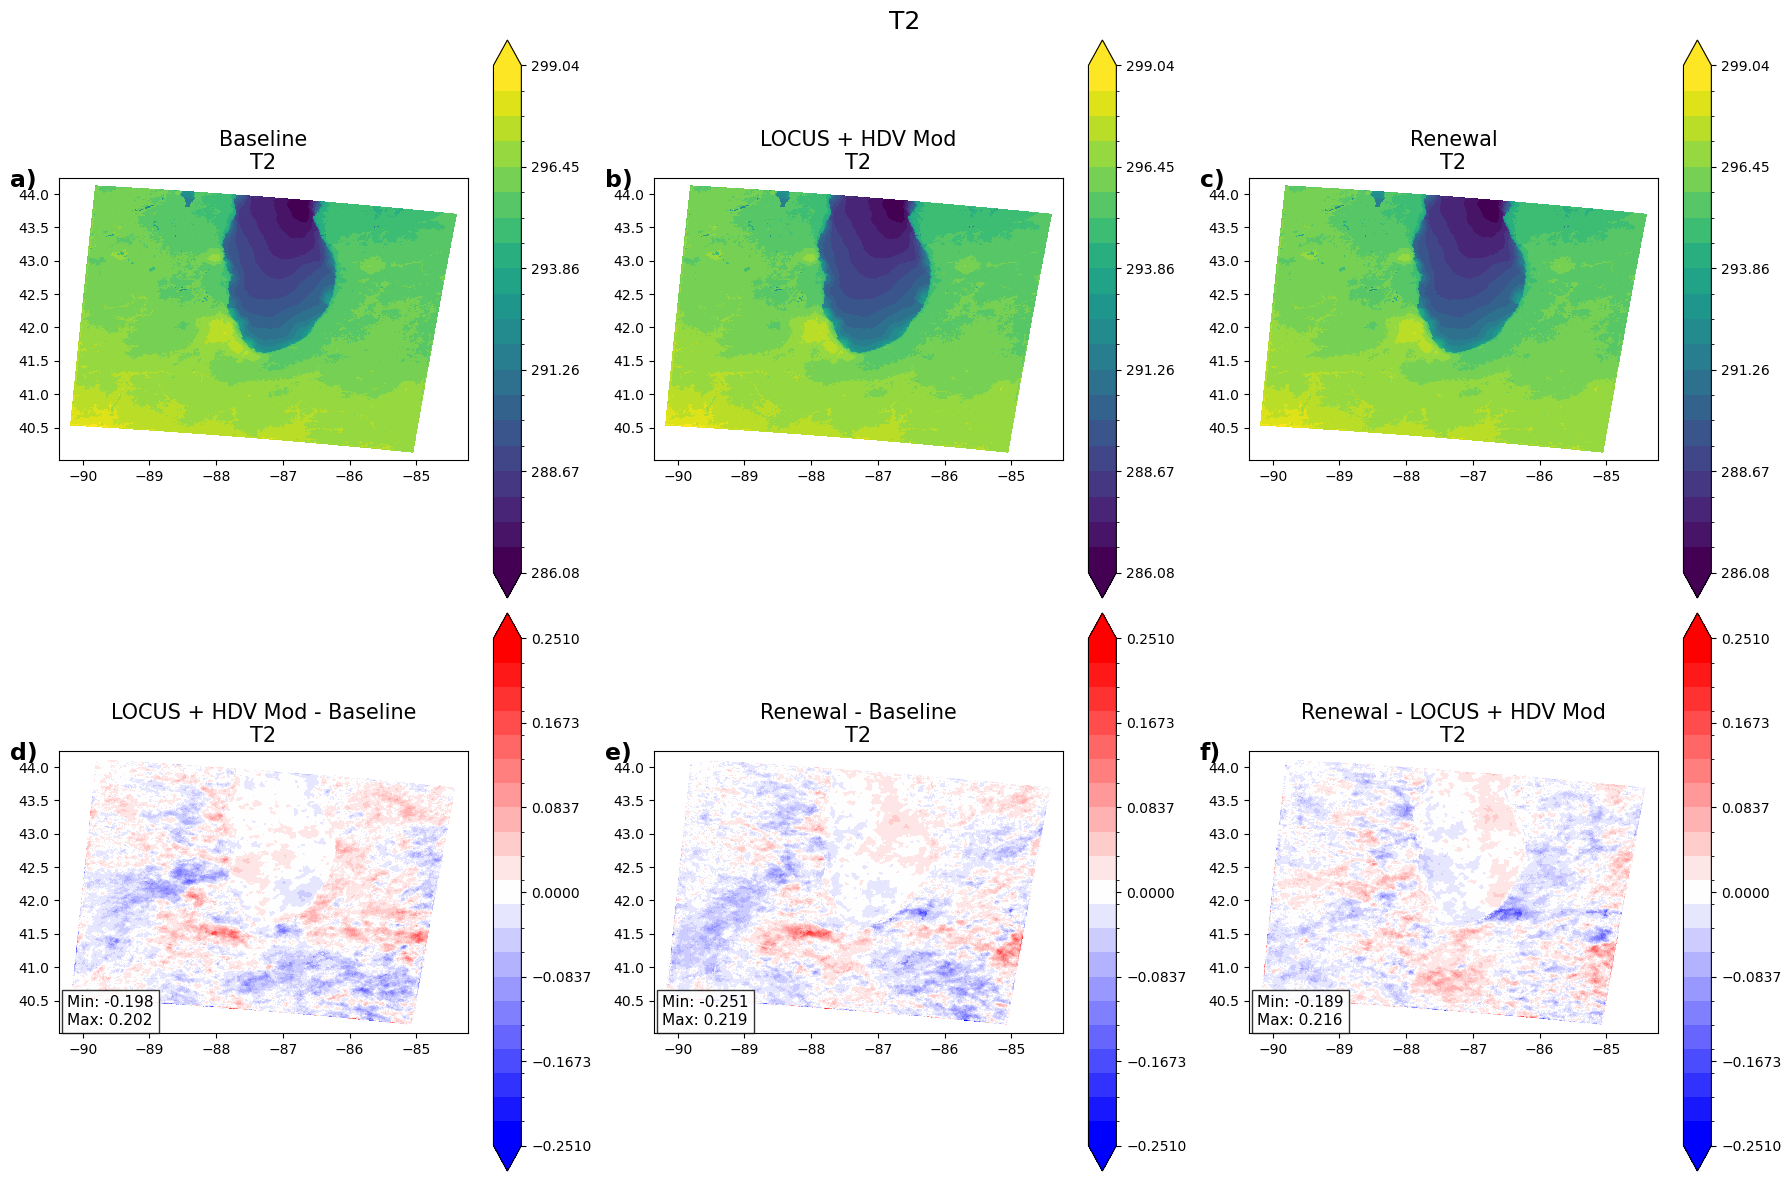

Plotting Q2 ...


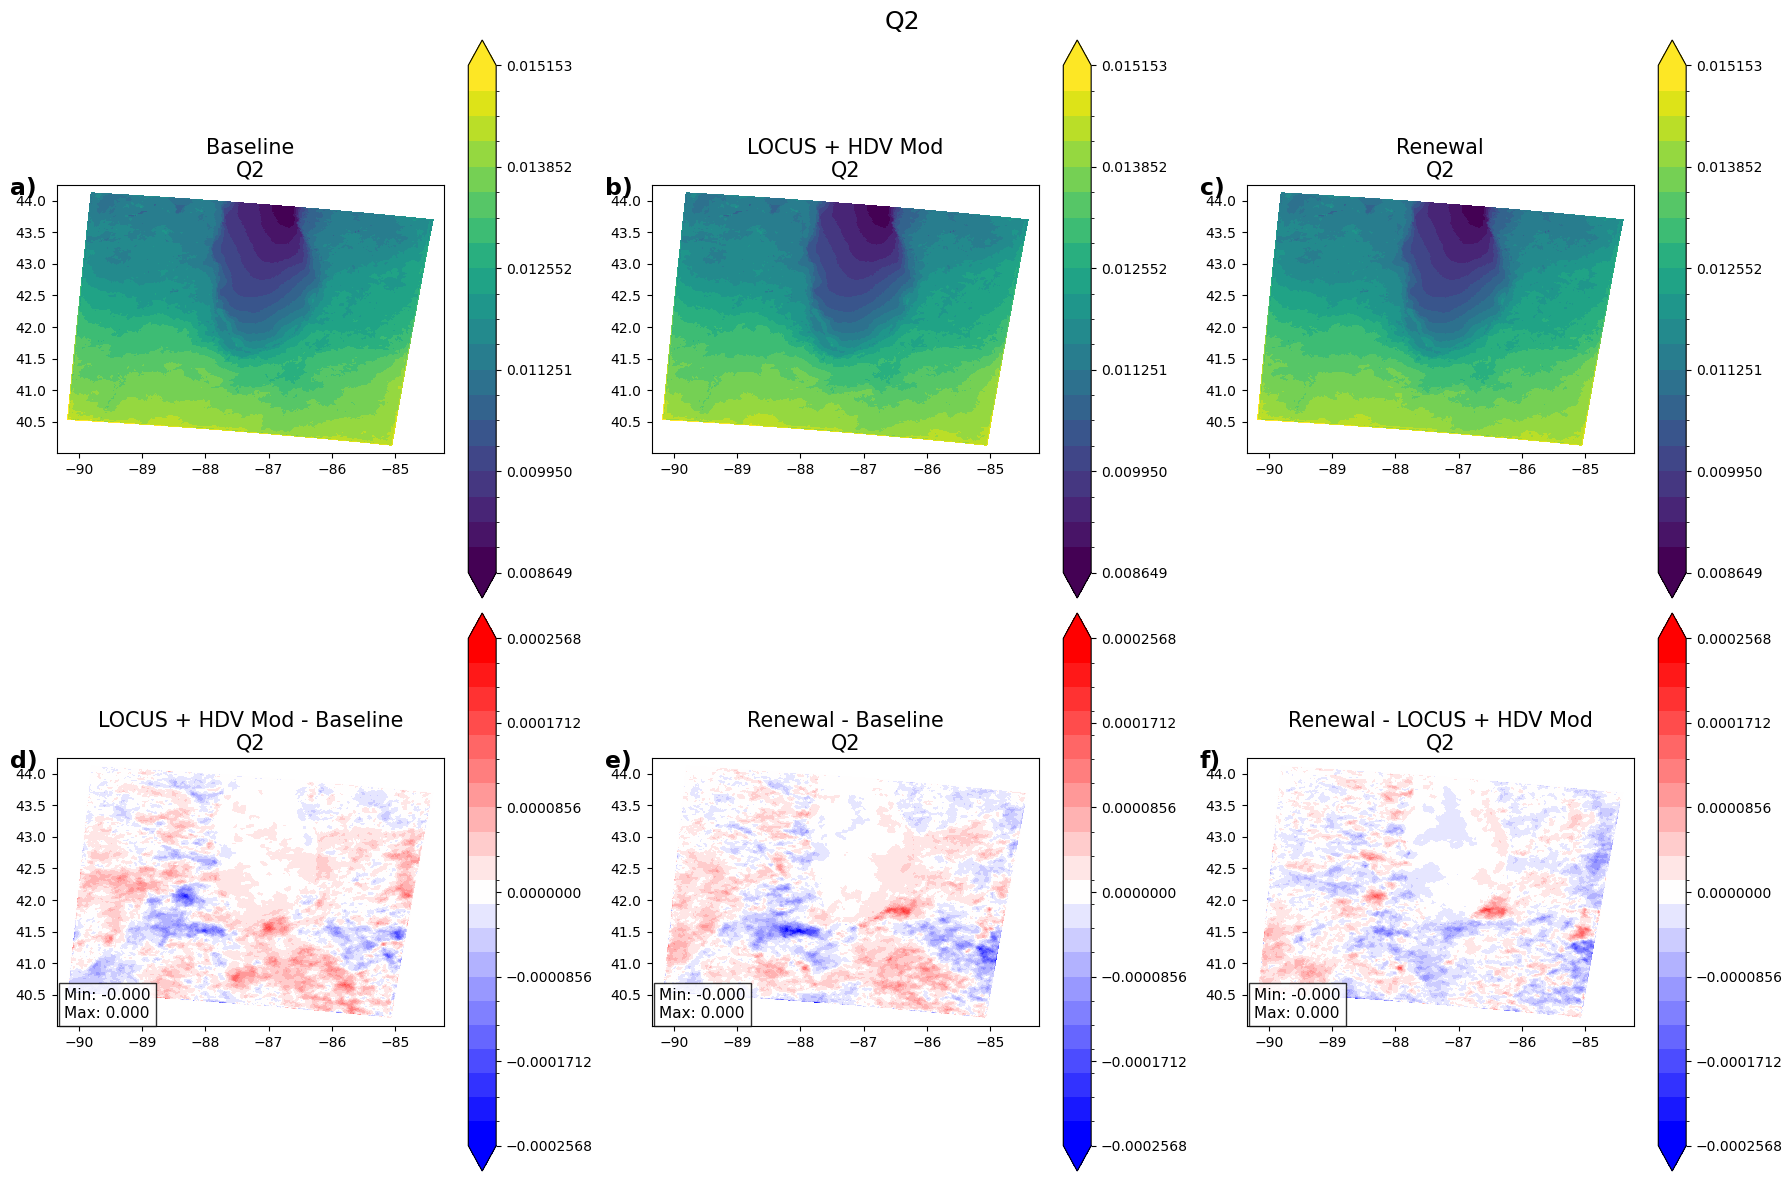

Plotting U10 ...


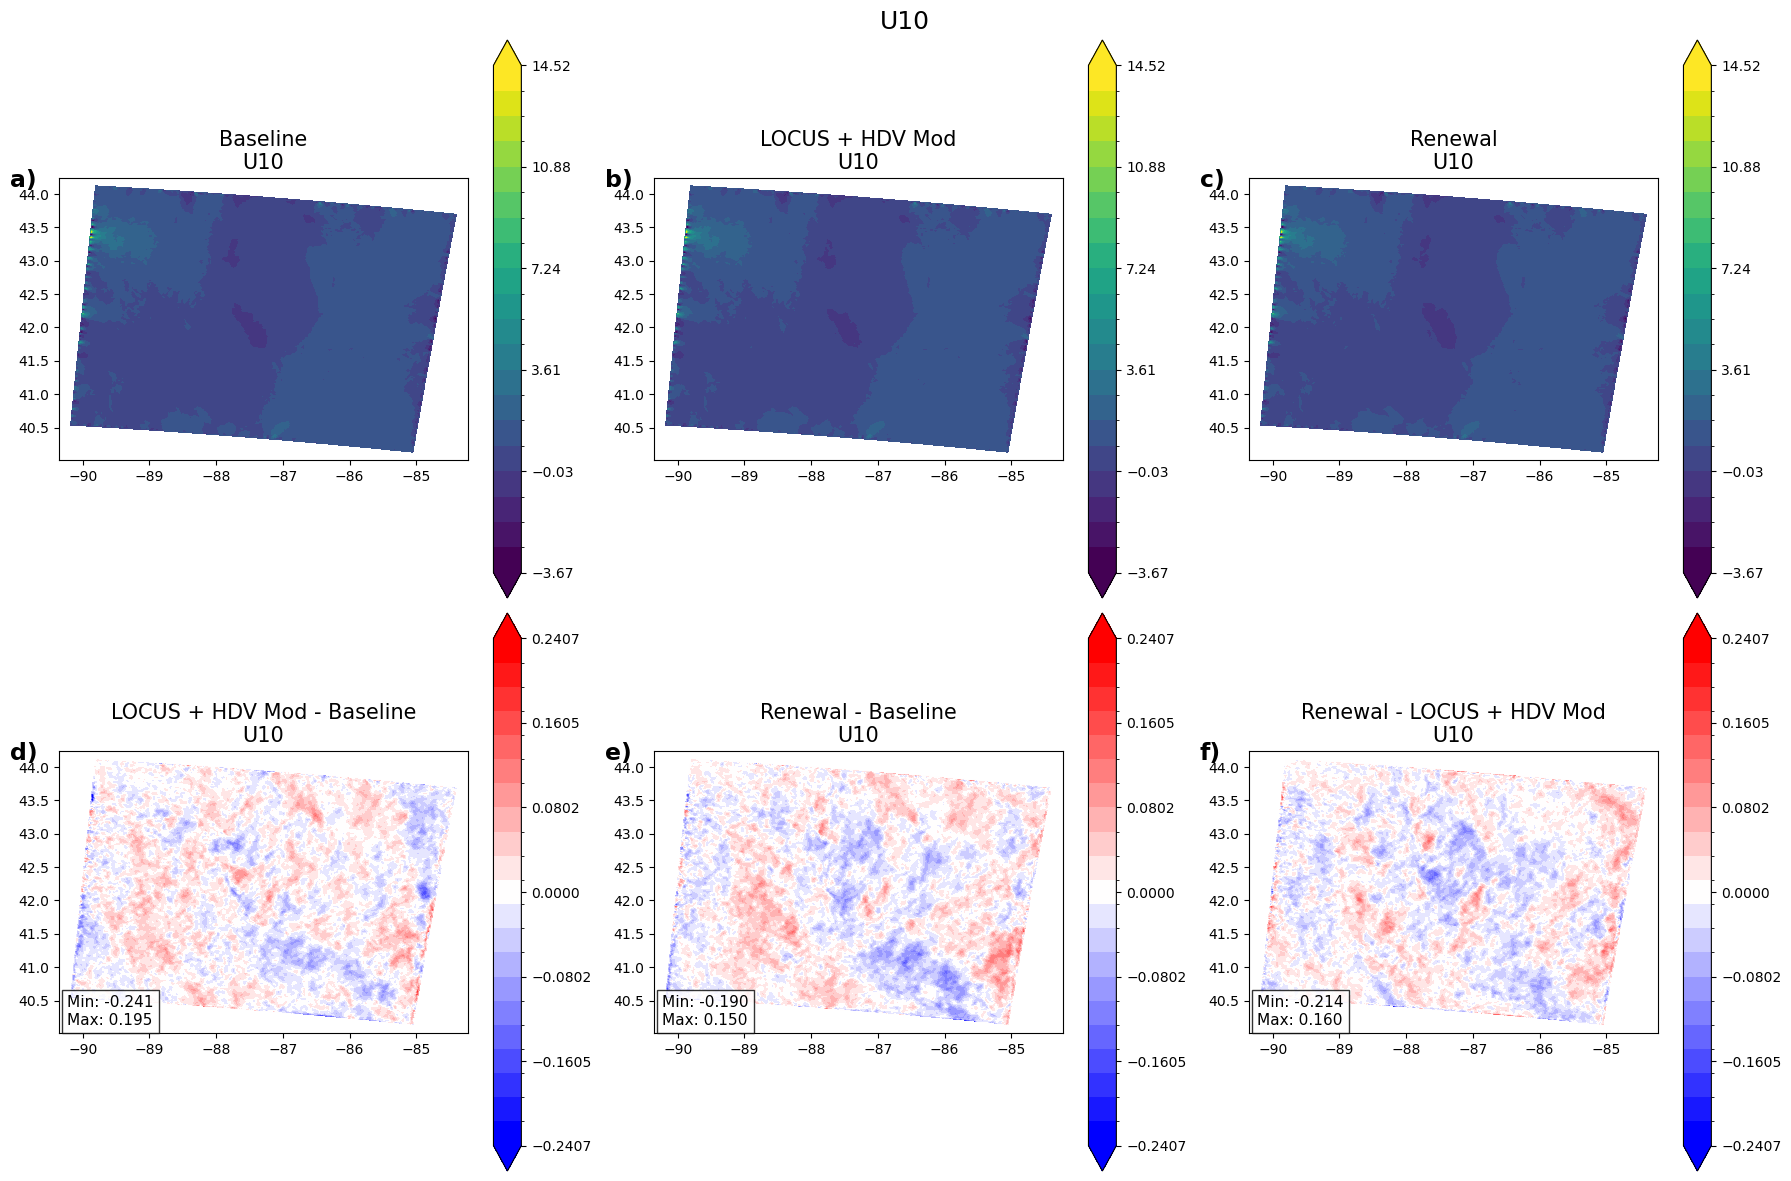

Plotting V10 ...


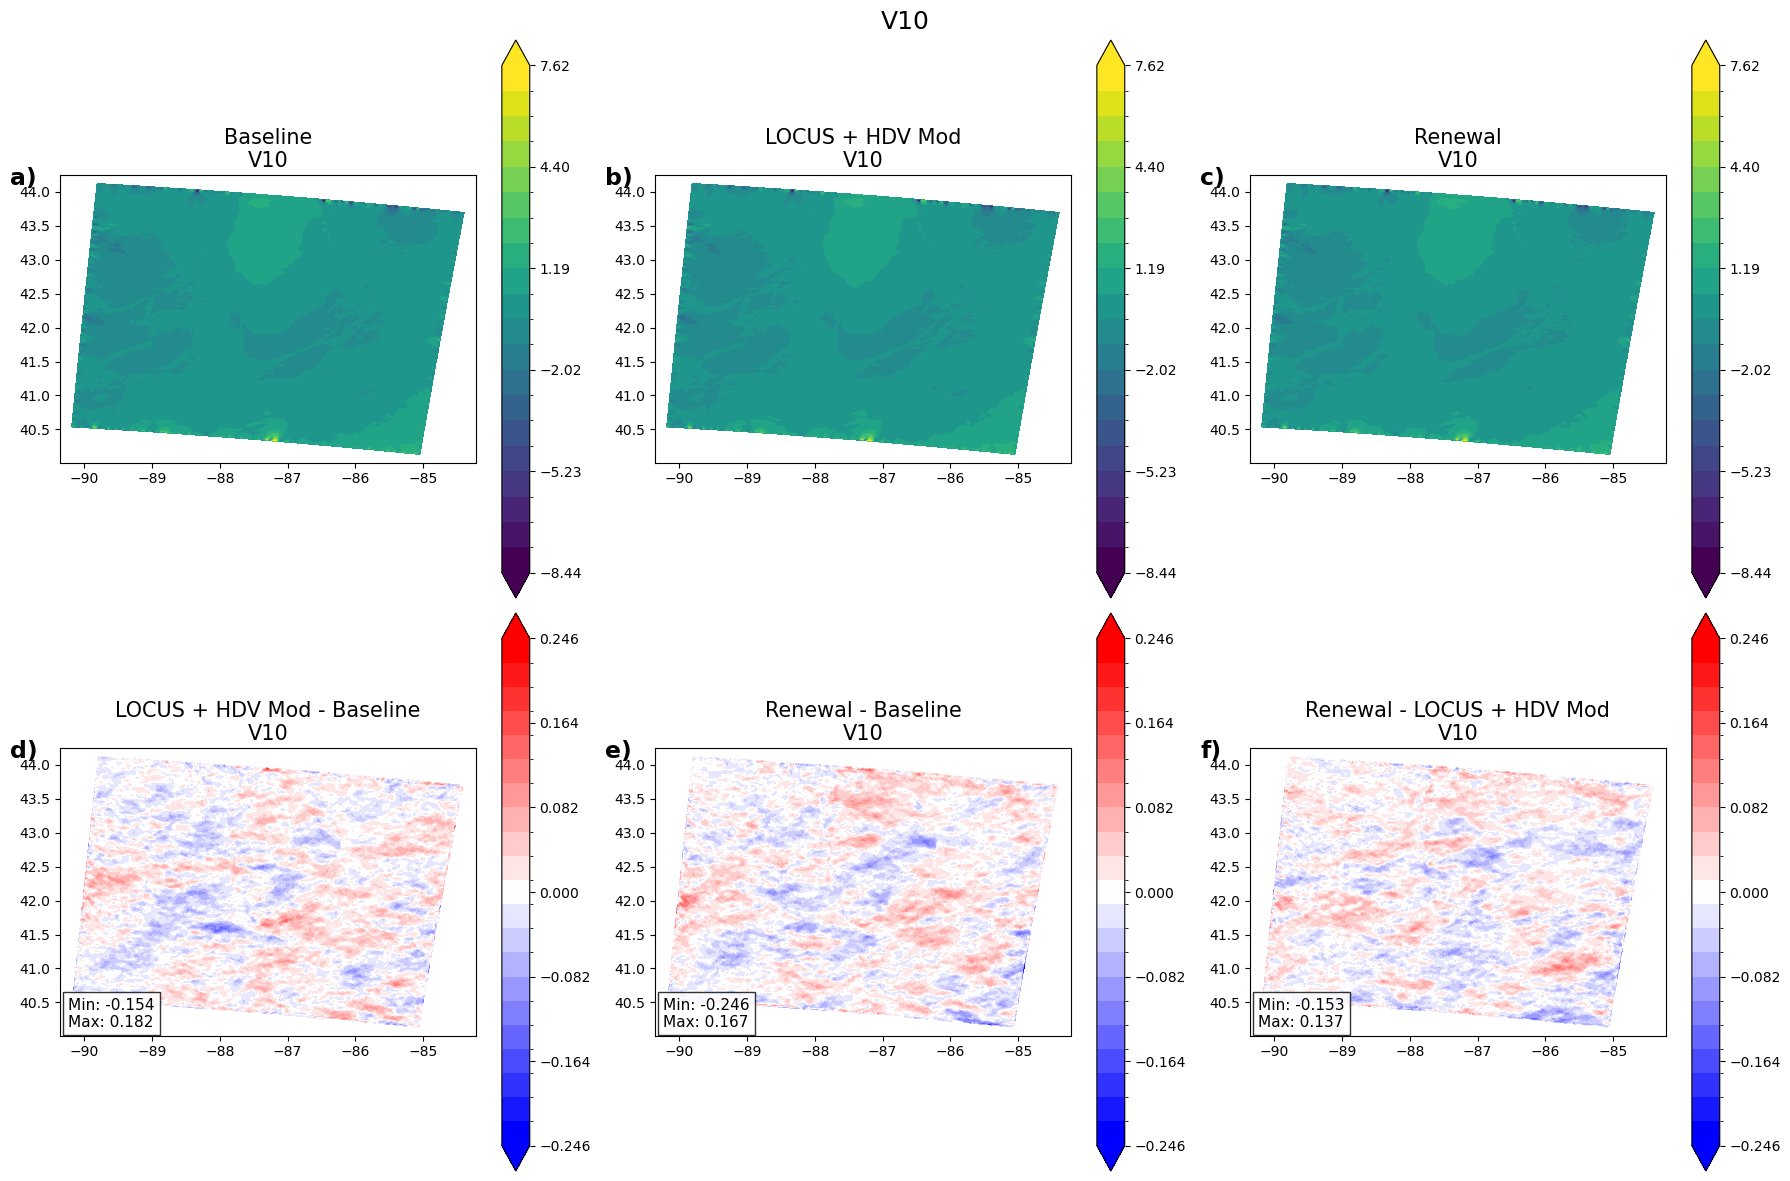

Plotting PSFC ...


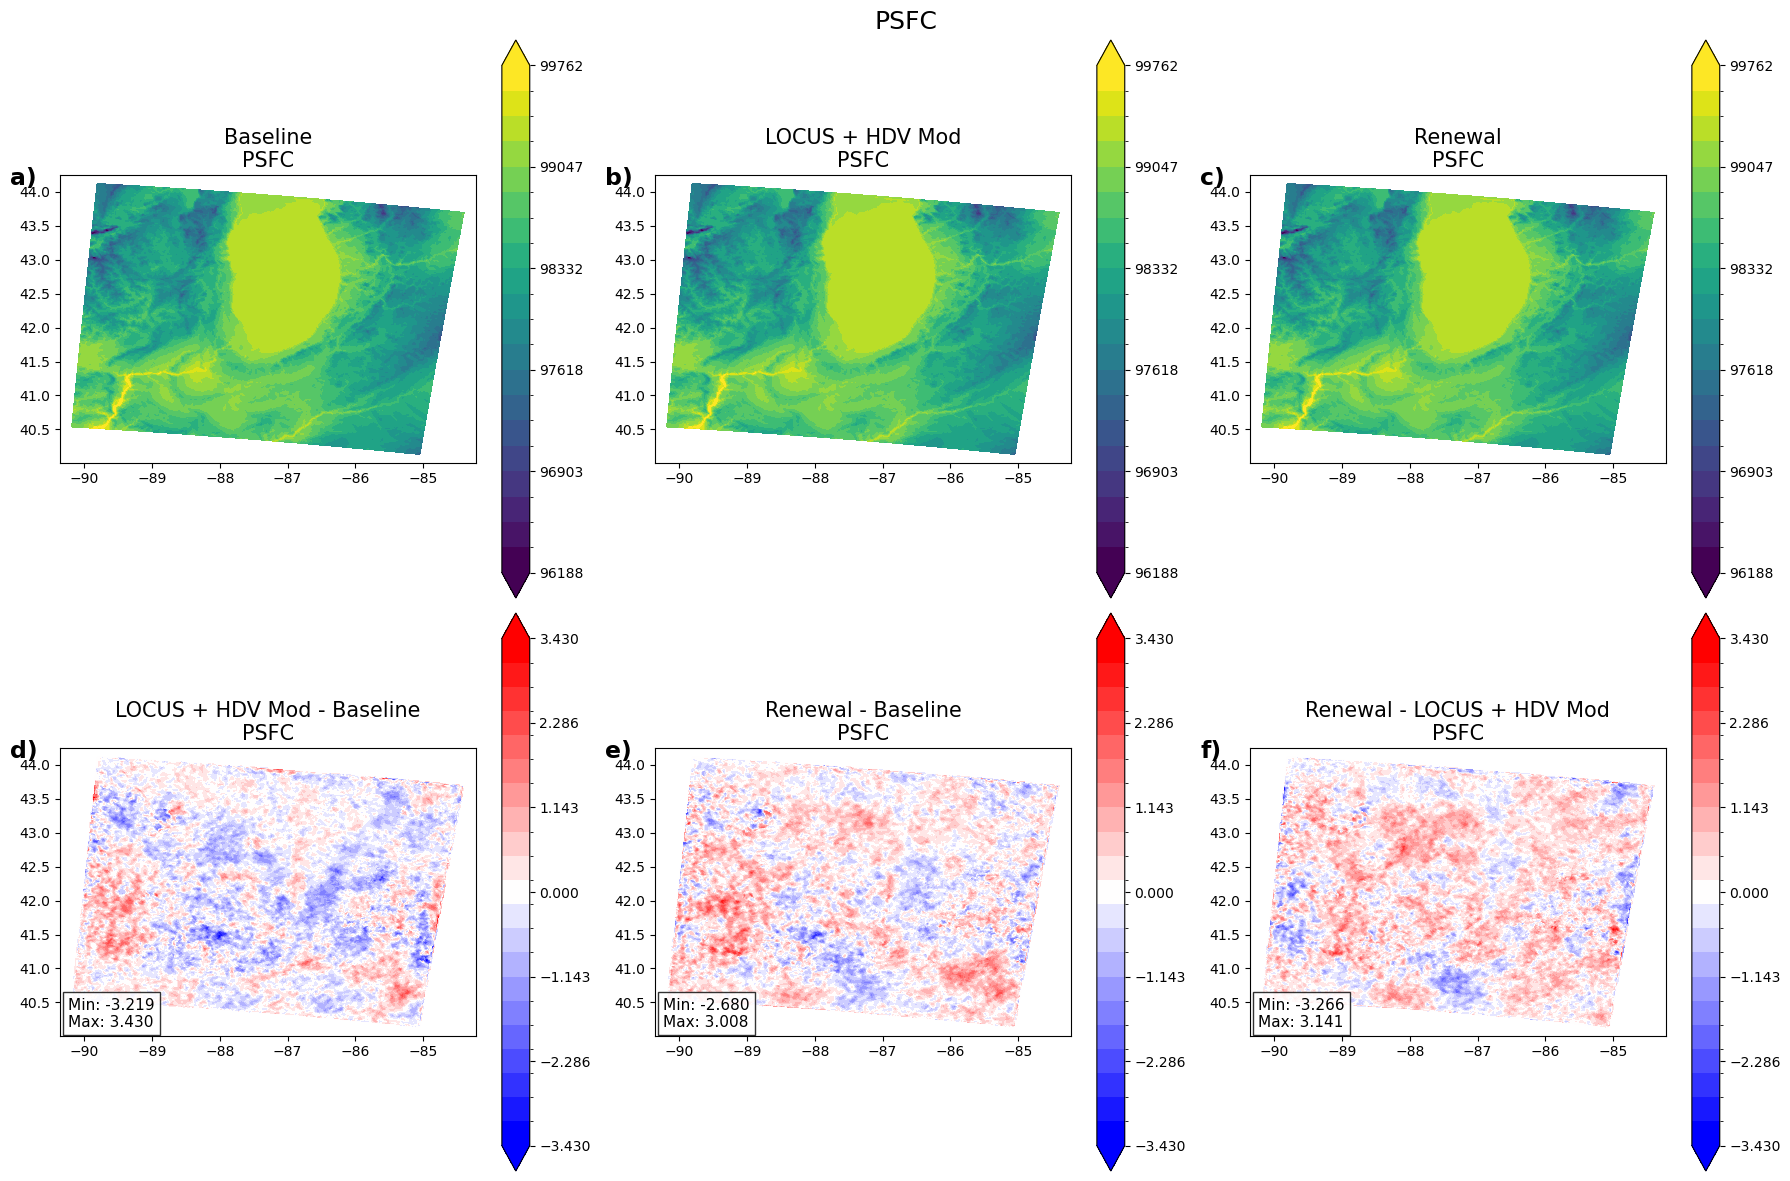

Plotting PBLH ...


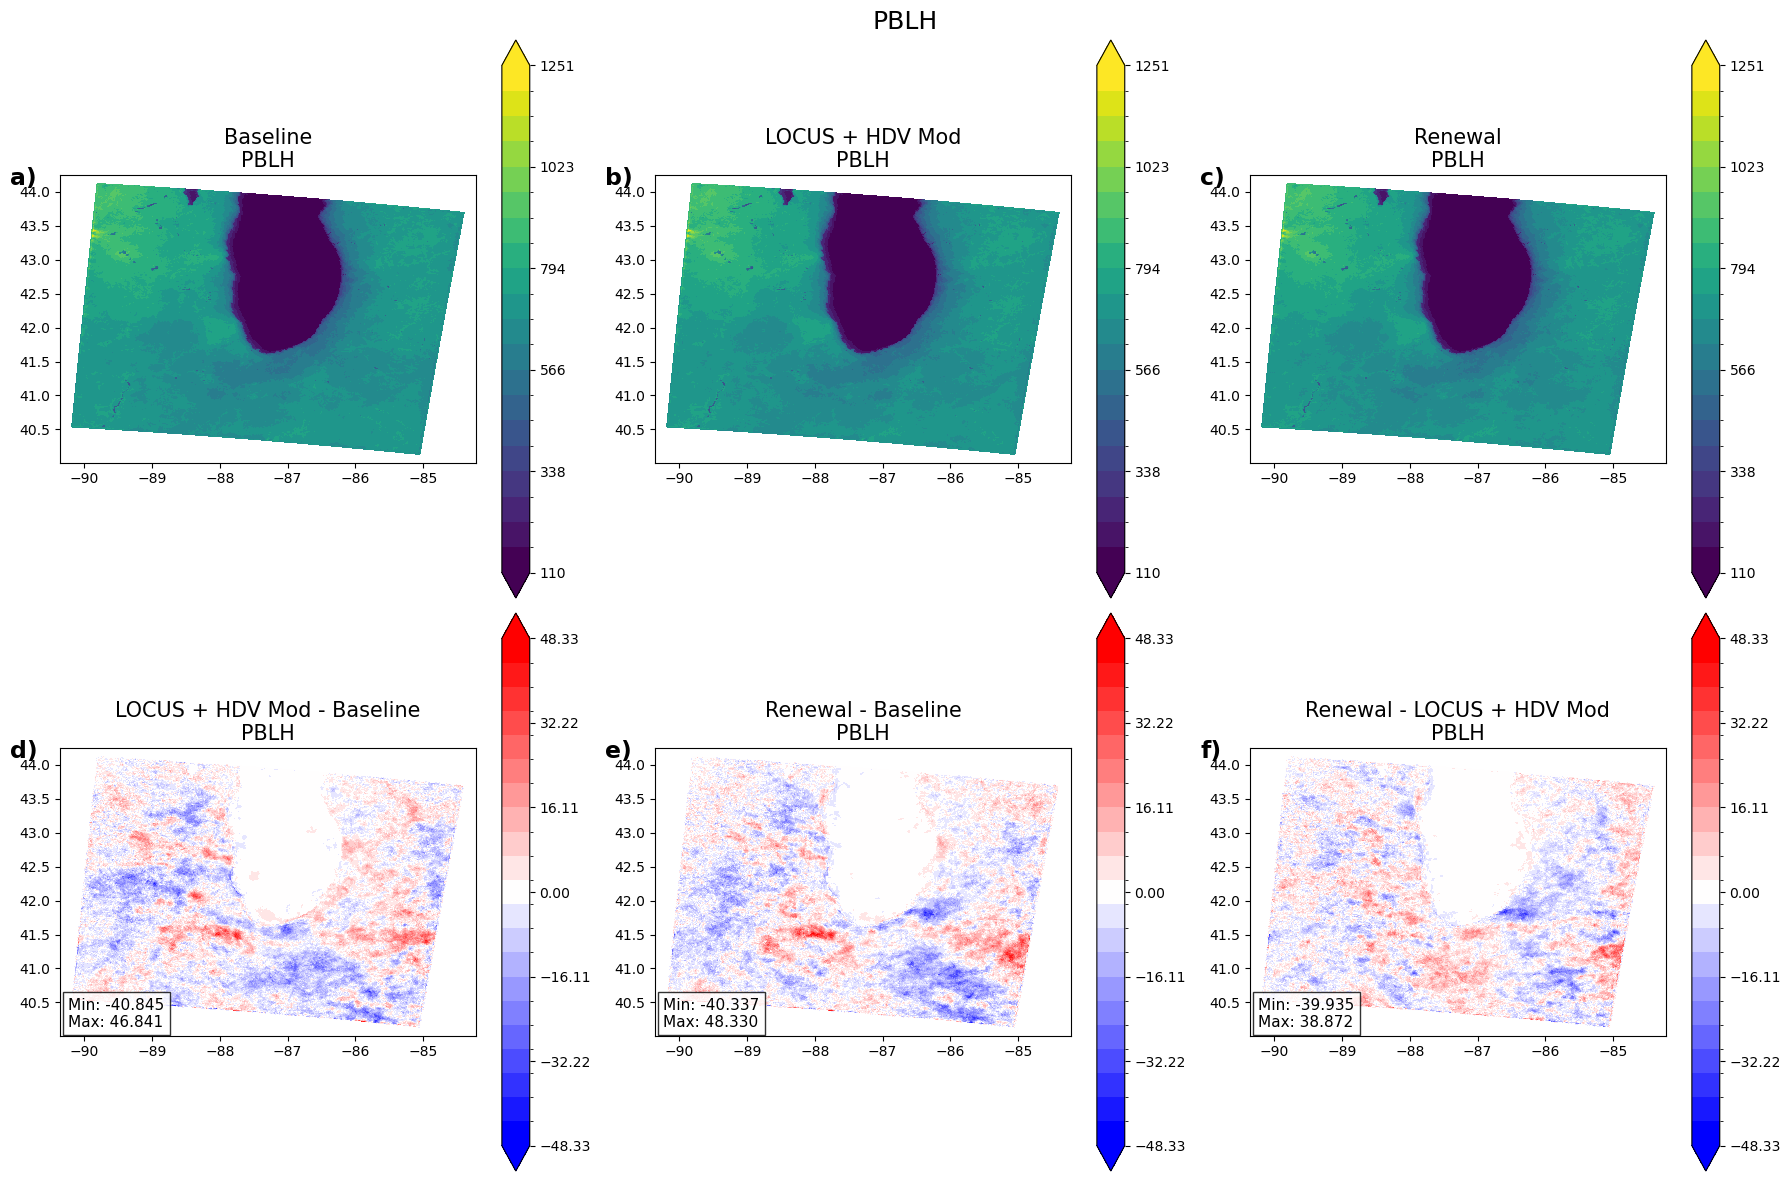

Plotting UST ...


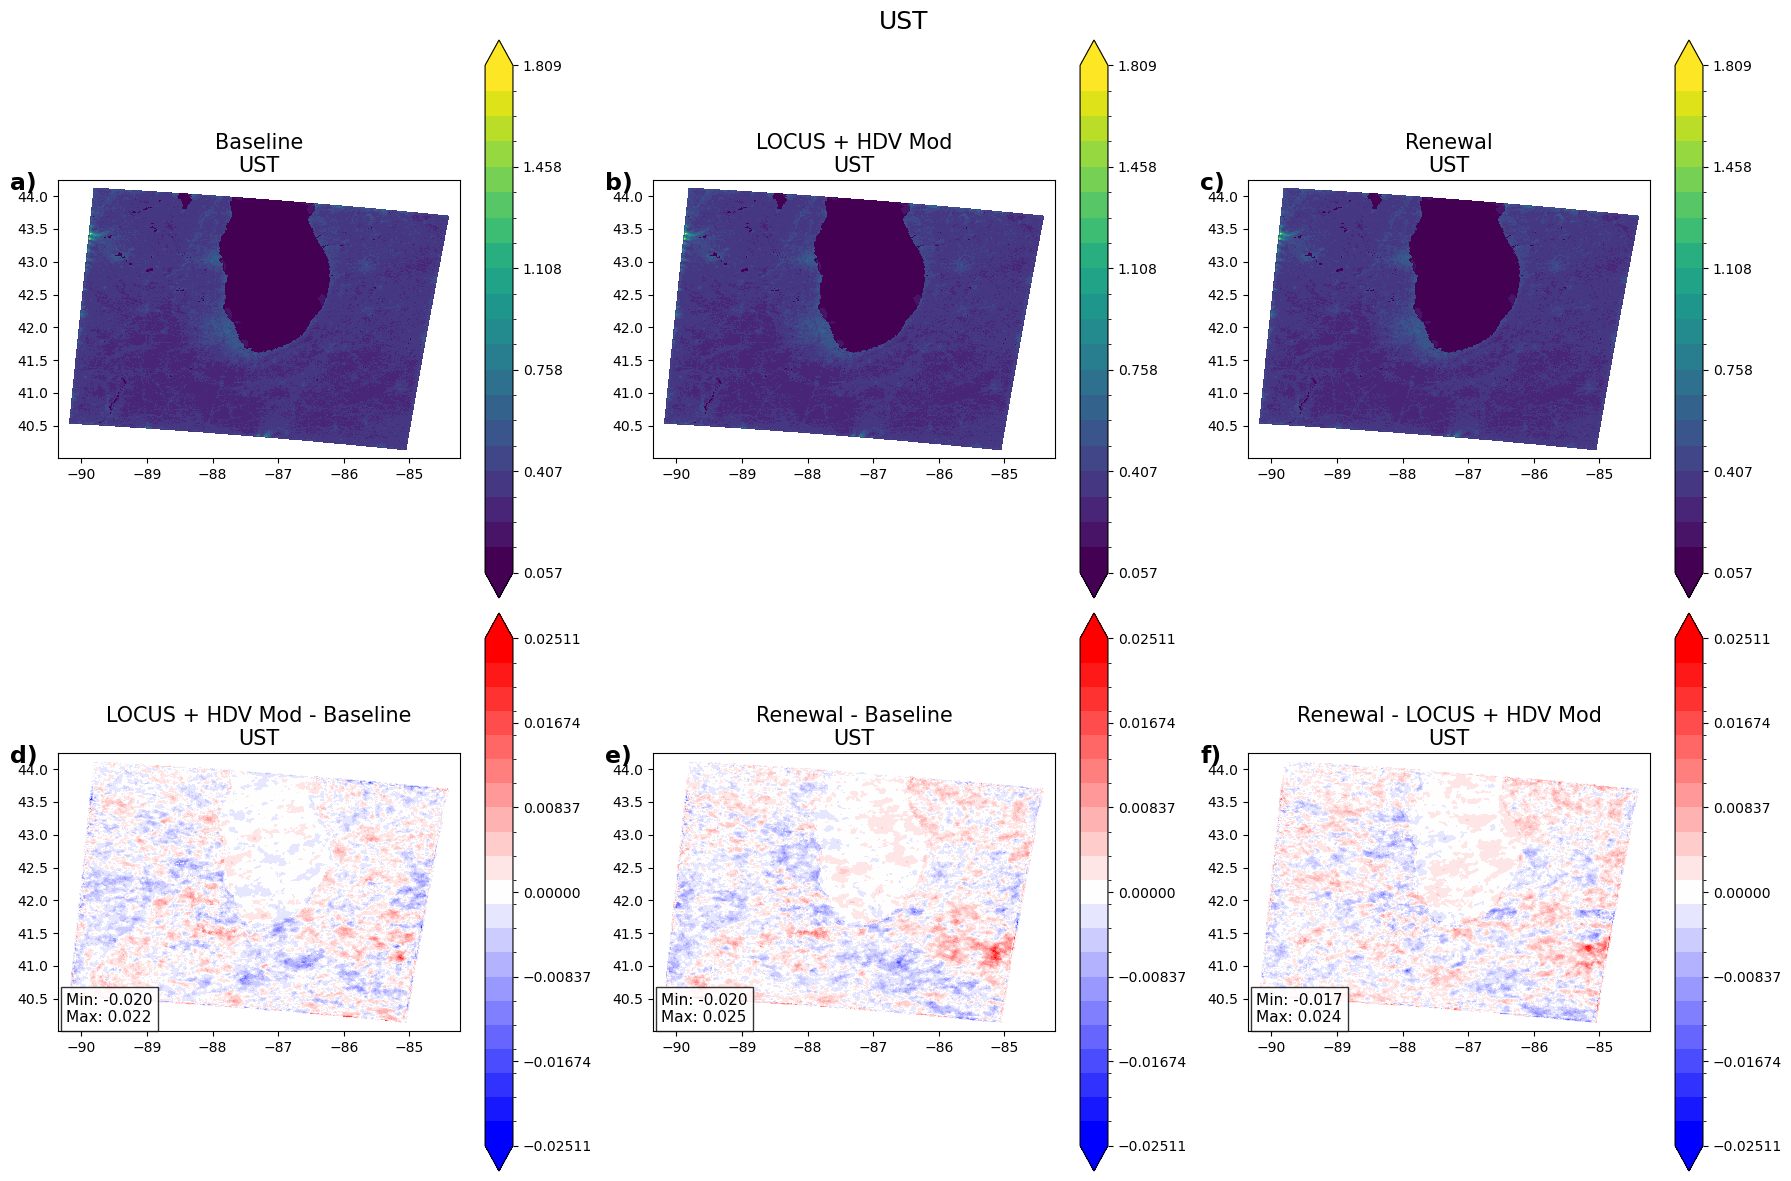

Plotting SWDOWN ...


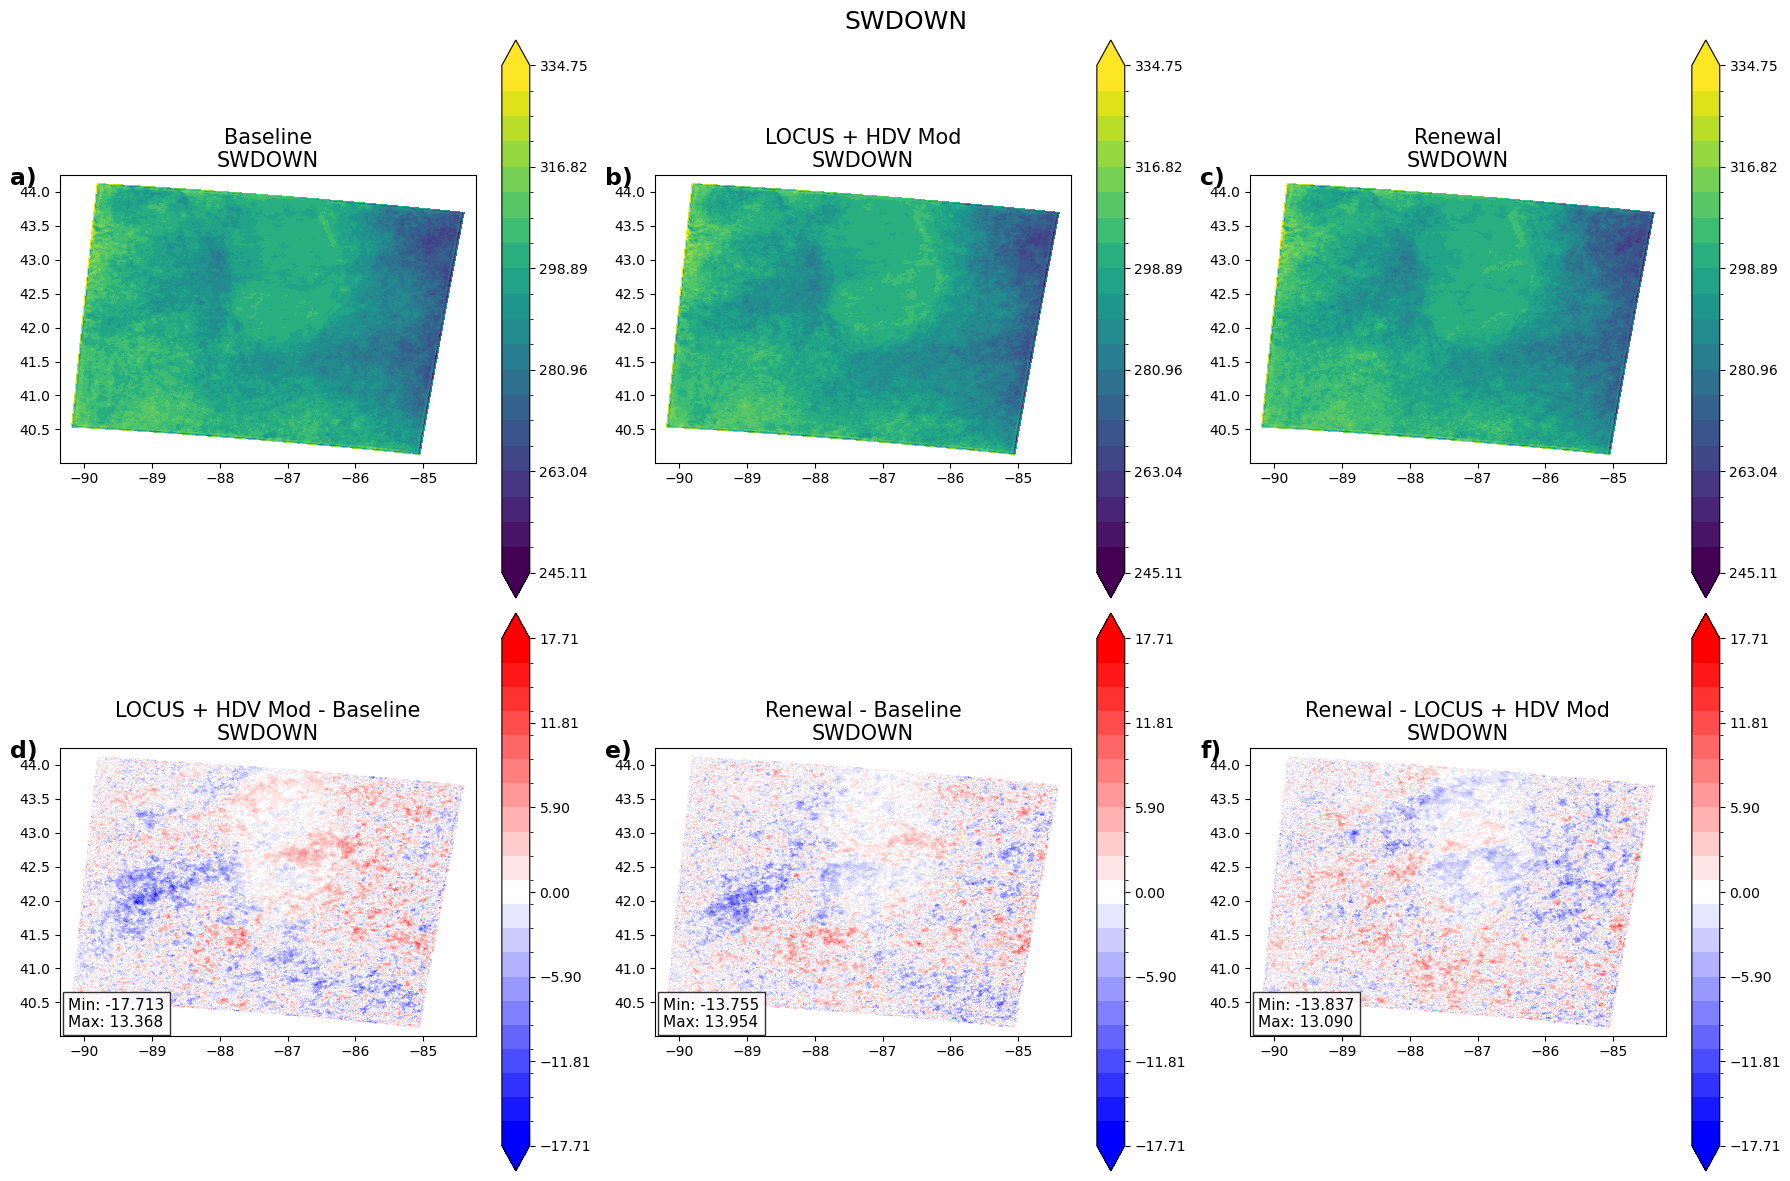

Plotting RAINC ...


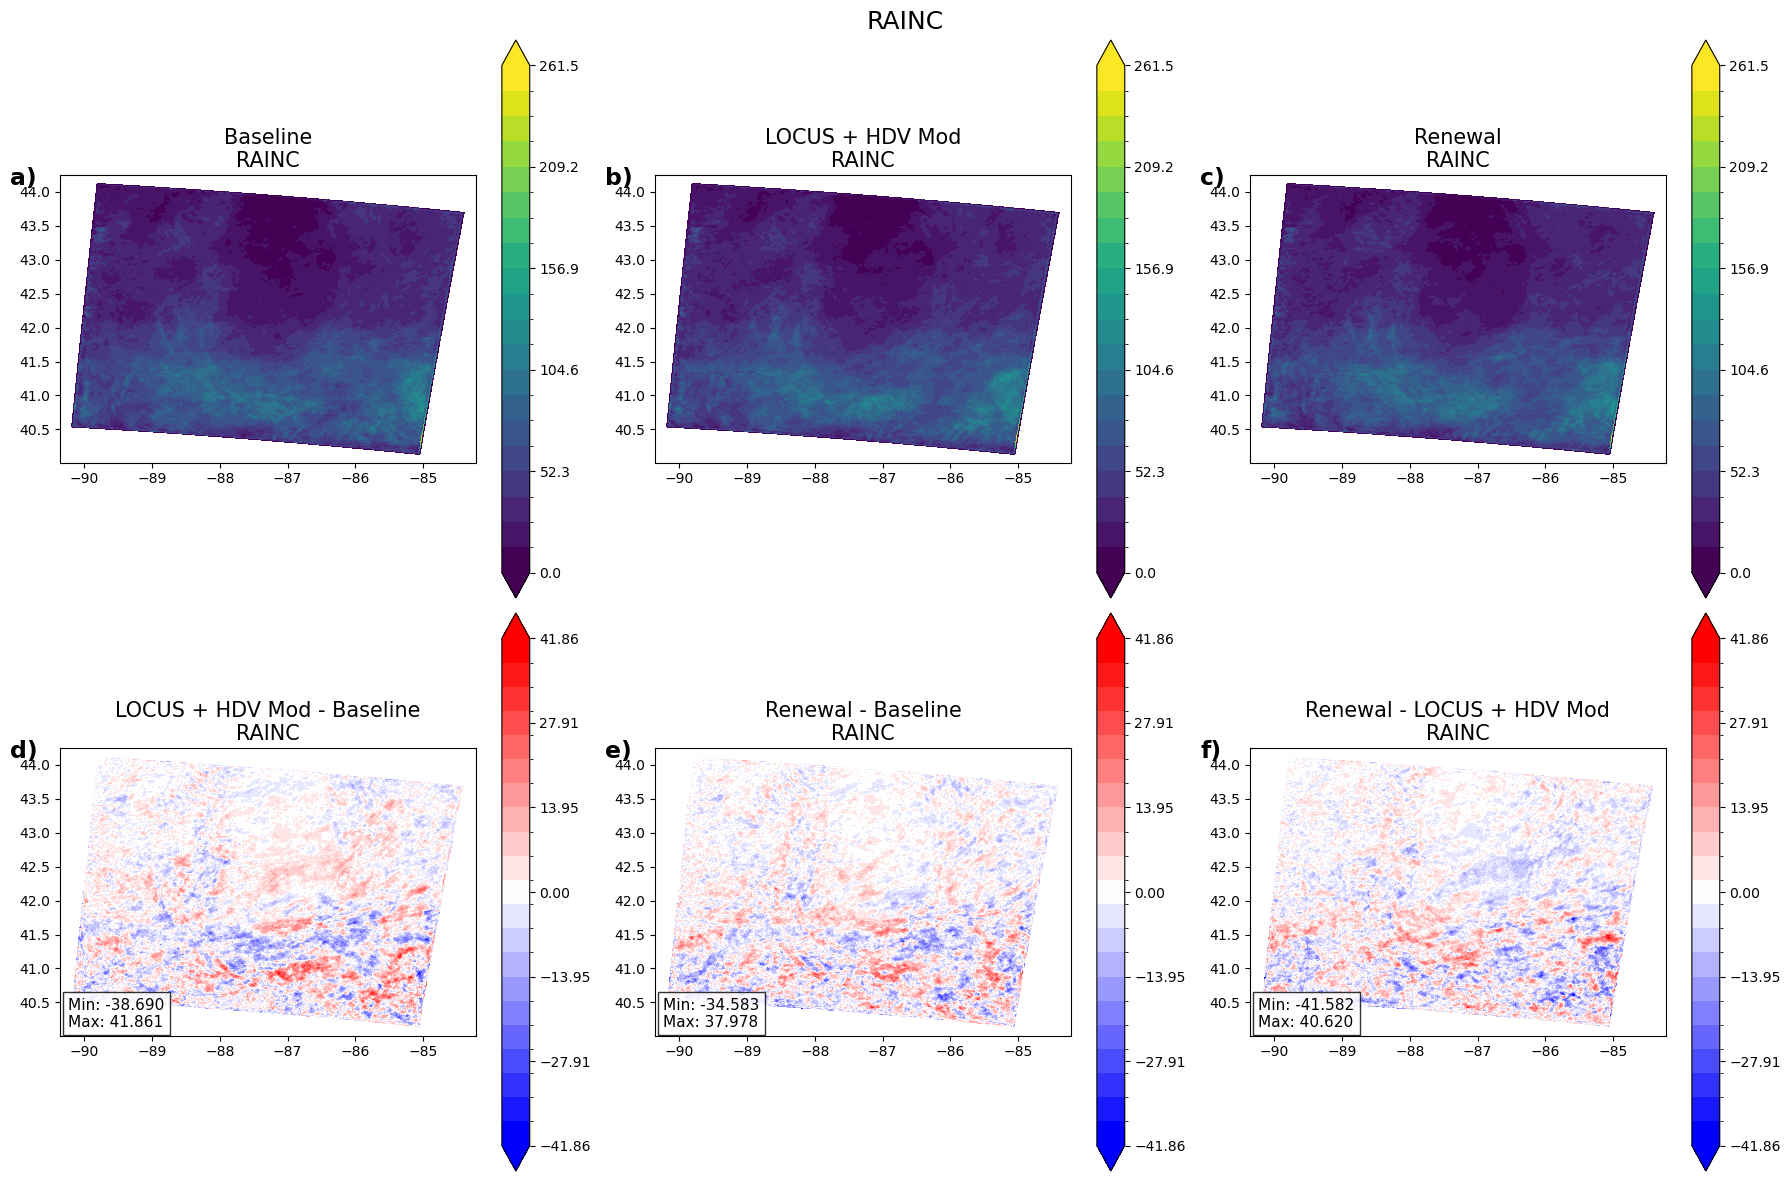

Plotting RAINNC ...


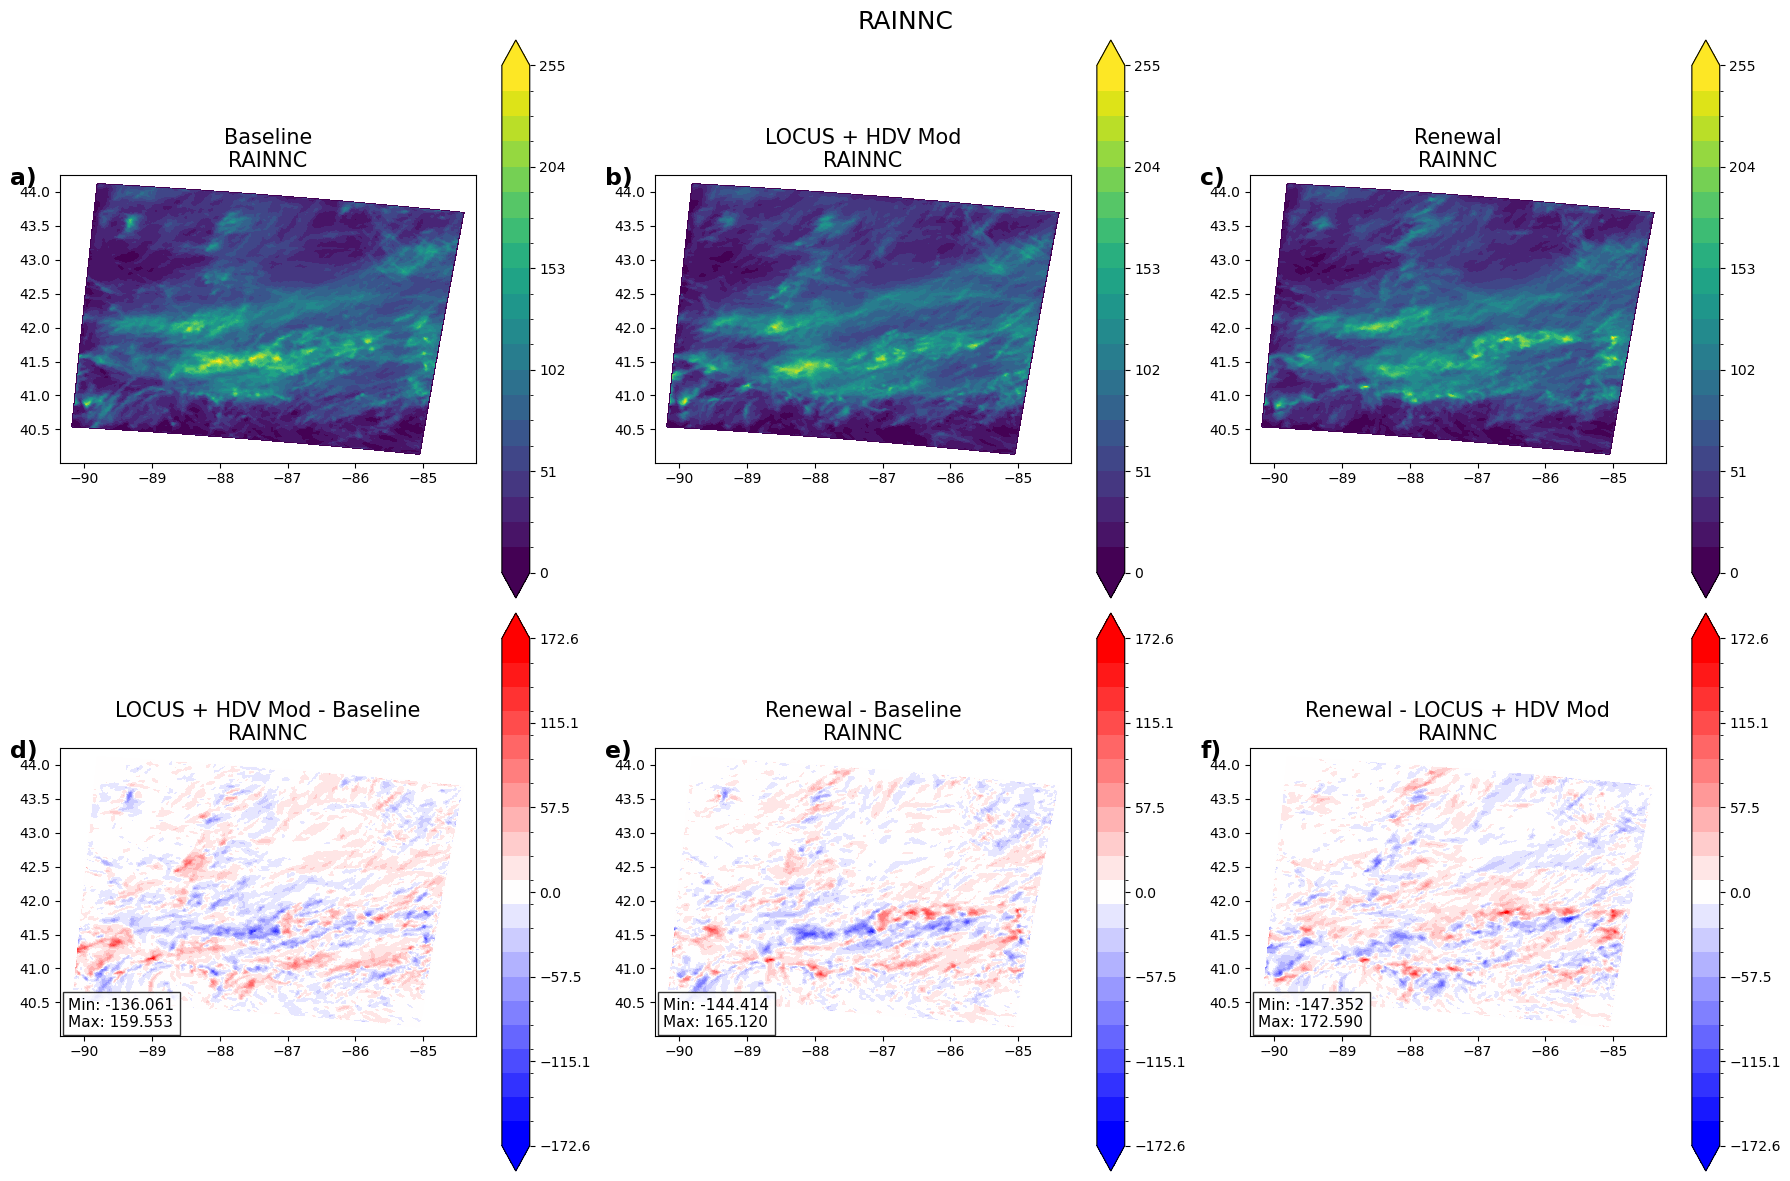

In [35]:
# loop through each variable
for var in shared_vars:

    print(f"Plotting {var} ...")

    # Pull fields from each dataset
    base_field = get_2d_field(base_ds[var]).values
    idling_field = get_2d_field(idling_ds[var]).values
    renewal_field = get_2d_field(renewal_ds[var]).values

    # Differences
    idling_minus_base = idling_field - base_field
    renewal_minus_base = renewal_field - base_field
    renewal_minus_idling = renewal_field - idling_field

    # min/max for annotations
    d1_min, d1_max = np.nanmin(idling_minus_base), np.nanmax(idling_minus_base)
    d2_min, d2_max = np.nanmin(renewal_minus_base), np.nanmax(renewal_minus_base)
    d3_min, d3_max = np.nanmin(renewal_minus_idling), np.nanmax(renewal_minus_idling)
   
    # Shared concentration color scale across first row
    conc_vals = np.concatenate([
        base_field.ravel(),
        idling_field.ravel(),
        renewal_field.ravel()
    ])
    conc_vals = conc_vals[np.isfinite(conc_vals)]

    if len(conc_vals) == 0:
        print(f"Skipping {var}: no finite values.")
        continue

    conc_vmin = np.nanmin(conc_vals)
    conc_vmax = np.nanmax(conc_vals)

    if conc_vmin == conc_vmax:
        conc_vmax = conc_vmin + 1e-12

    conc_bounds = np.linspace(conc_vmin, conc_vmax, N_CONC_BINS + 1)
    conc_norm = BoundaryNorm(conc_bounds, viridis_disc.N)
    conc_ticks = np.linspace(conc_vmin, conc_vmax, 6)

    # Shared difference color scale across second row
    diff_vals = np.concatenate([
        idling_minus_base.ravel(),
        renewal_minus_base.ravel(),
        renewal_minus_idling.ravel()
    ])
    diff_vals = diff_vals[np.isfinite(diff_vals)]

    if len(diff_vals) == 0:
        diff_absmax = 1e-12
    else:
        diff_absmax = np.nanmax(np.abs(diff_vals))

    if not np.isfinite(diff_absmax) or diff_absmax == 0:
        diff_absmax = 1e-12

    diff_vmin = -diff_absmax
    diff_vmax = diff_absmax

    diff_bounds = np.linspace(diff_vmin, diff_vmax, N_DIFF_BINS + 1)
    diff_norm = BoundaryNorm(diff_bounds, bwr_disc.N)
    diff_ticks = np.linspace(diff_vmin, diff_vmax, 7)

    # Figure 
    fig, axs = plt.subplots(2, 3, figsize=(18, 12))
    axs = axs.flatten()

    panel_labels = ["a)", "b)", "c)", "d)", "e)", "f)"]

    # Panel a: baseline
    axs[0].set_title(f"Baseline\n{var}", fontsize=15)
    im0 = axs[0].pcolormesh(
        cmaq_lon, cmaq_lat, base_field,
        cmap=viridis_disc,
        norm=conc_norm,
        shading='auto'
    )
    cbar0 = plt.colorbar(im0, ax=axs[0], orientation='vertical', extend='both')
    cbar0.set_ticks(conc_ticks)

    axs[0].set_xlim(xmin - pad_x, xmax + pad_x)
    axs[0].set_ylim(ymin - pad_y, ymax + pad_y)
    axs[0].set_aspect('equal', adjustable='box')
    axs[0].text(-0.12, 1.03, panel_labels[0], transform=axs[0].transAxes,
                fontsize=17, fontweight="bold", va="top")

    # Panel b: idling
    axs[1].set_title(f"LOCUS + HDV Mod\n{var}", fontsize=15)
    im1 = axs[1].pcolormesh(
        cmaq_lon, cmaq_lat, idling_field,
        cmap=viridis_disc,
        norm=conc_norm,
        shading='auto'
    )
    cbar1 = plt.colorbar(im1, ax=axs[1], orientation='vertical', extend='both')
    cbar1.set_ticks(conc_ticks)

    axs[1].set_xlim(xmin - pad_x, xmax + pad_x)
    axs[1].set_ylim(ymin - pad_y, ymax + pad_y)
    axs[1].set_aspect('equal', adjustable='box')
    axs[1].text(-0.12, 1.03, panel_labels[1], transform=axs[1].transAxes,
                fontsize=17, fontweight="bold", va="top")

    # Panel c: renewal
    axs[2].set_title(f"Renewal\n{var}", fontsize=15)
    im2 = axs[2].pcolormesh(
        cmaq_lon, cmaq_lat, renewal_field,
        cmap=viridis_disc,
        norm=conc_norm,
        shading='auto'
    )
    cbar2 = plt.colorbar(im2, ax=axs[2], orientation='vertical', extend='both')
    cbar2.set_ticks(conc_ticks)

    axs[2].set_xlim(xmin - pad_x, xmax + pad_x)
    axs[2].set_ylim(ymin - pad_y, ymax + pad_y)
    axs[2].set_aspect('equal', adjustable='box')
    axs[2].text(-0.12, 1.03, panel_labels[2], transform=axs[2].transAxes,
                fontsize=17, fontweight="bold", va="top")

    # Panel d: idling - baseline
    axs[3].set_title(f"LOCUS + HDV Mod - Baseline\n{var}", fontsize=15)
    im3 = axs[3].pcolormesh(
        cmaq_lon, cmaq_lat, idling_minus_base,
        cmap=bwr_disc,
        norm=diff_norm,
        shading='auto'
    )
    cbar3 = plt.colorbar(im3, ax=axs[3], orientation='vertical', extend='both')
    cbar3.set_ticks(diff_ticks)

    axs[3].set_xlim(xmin - pad_x, xmax + pad_x)
    axs[3].set_ylim(ymin - pad_y, ymax + pad_y)
    axs[3].set_aspect('equal', adjustable='box')
    axs[3].text(-0.12, 1.03, panel_labels[3], transform=axs[3].transAxes,
                fontsize=17, fontweight="bold", va="top")
    axs[3].text(
        0.02, 0.02,
        f"Min: {d1_min:.3f}\nMax: {d1_max:.3f}",
        transform=axs[3].transAxes,
        fontsize=11,
        va='bottom',
        ha='left',
        bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
    )
    # Panel e: renewal - baseline
    axs[4].set_title(f"Renewal - Baseline\n{var}", fontsize=15)
    im4 = axs[4].pcolormesh(
        cmaq_lon, cmaq_lat, renewal_minus_base,
        cmap=bwr_disc,
        norm=diff_norm,
        shading='auto'
    )
    cbar4 = plt.colorbar(im4, ax=axs[4], orientation='vertical', extend='both')
    cbar4.set_ticks(diff_ticks)

    axs[4].set_xlim(xmin - pad_x, xmax + pad_x)
    axs[4].set_ylim(ymin - pad_y, ymax + pad_y)
    axs[4].set_aspect('equal', adjustable='box')
    axs[4].text(-0.12, 1.03, panel_labels[4], transform=axs[4].transAxes,
                fontsize=17, fontweight="bold", va="top")
    axs[4].text(
        0.02, 0.02,
        f"Min: {d2_min:.3f}\nMax: {d2_max:.3f}",
        transform=axs[4].transAxes,
        fontsize=11,
        va='bottom',
        ha='left',
        bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
    )
    # ========================================================
    # Panel f: renewal - idling
    # ========================================================
    axs[5].set_title(f"Renewal - LOCUS + HDV Mod\n{var}", fontsize=15)
    im5 = axs[5].pcolormesh(
        cmaq_lon, cmaq_lat, renewal_minus_idling,
        cmap=bwr_disc,
        norm=diff_norm,
        shading='auto'
    )
    cbar5 = plt.colorbar(im5, ax=axs[5], orientation='vertical', extend='both')
    cbar5.set_ticks(diff_ticks)

    axs[5].set_xlim(xmin - pad_x, xmax + pad_x)
    axs[5].set_ylim(ymin - pad_y, ymax + pad_y)
    axs[5].set_aspect('equal', adjustable='box')
    axs[5].text(-0.12, 1.03, panel_labels[5], transform=axs[5].transAxes,
                fontsize=17, fontweight="bold", va="top")
    axs[5].text(
        0.02, 0.02,
        f"Min: {d3_min:.3f}\nMax: {d3_max:.3f}",
        transform=axs[5].transAxes,
        fontsize=11,
        va='bottom',
        ha='left',
        bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
    )
    # --------------------------------------------------------
    # Clean up axis labels
    # --------------------------------------------------------
    for ax in axs:
        ax.set_xlabel("")
        ax.set_ylabel("")

    plt.suptitle(var, fontsize=18, y=0.98)
    plt.tight_layout()

    # --------------------------------------------------------
    # Save and/or show
    # --------------------------------------------------------
    if save_figs:
        plt.savefig(
            os.path.join(outdir, f"{var}_maps.tiff"),
            dpi=300,
            format="tiff",
            bbox_inches="tight"
        )

    if show_figs:
        plt.show()
    else:
        plt.close()

In [29]:
base_ds.close()
idling_ds.close()
renewal_ds.close()